# Women's tour investigation: actual points per consensus games line

For each women's tournament level (`wta_250`, `wta_500`, `wta_1000`, `grand_slam`):
- metric = `total_points / projected_total_games`
- one stacked chart of tournament-level means (vs level-wide mean)
- one matches-per-tournament chart

Same filtered curation pipeline as the OJ MLE notebooks.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "injestion").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError(f"Could not find project root from {cwd}")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from injestion.core.bq import get_client
from originated_models.total_points_oj_data import DEFAULT_TEST_CUTOFF, load_train_test_frames

bq_client = get_client()
print(f"Project: {bq_client.project}")

Project: prizepicksanalytics


## Load women's matches

In [2]:
WOMEN_LEVELS = ["wta_250", "wta_500", "wta_1000", "grand_slam"]

data = load_train_test_frames(bq_client, test_cutoff=DEFAULT_TEST_CUTOFF)
base = data["all_split_df"].copy() if "all_split_df" in data else data["filtered_df"].copy()

women = base.loc[base["category_name"].astype("string").str.upper() == "WTA"].copy()
women["competition_level"] = (
    women["competition_level"].astype("string").str.lower().str.strip()
)
women = women.loc[women["competition_level"].isin(WOMEN_LEVELS)].copy()

for c in ("total_points", "projected_total_games", "total_games_played"):
    women[c] = pd.to_numeric(women[c], errors="coerce")

women = women.dropna(subset=["total_points", "projected_total_games", "season_id"]).copy()
women = women.loc[women["projected_total_games"] > 0].copy()
women["points_per_projected_game"] = women["total_points"] / women["projected_total_games"]
women["start_time"] = pd.to_datetime(women["start_time"], utc=True, errors="coerce")

print(
    f"Women's matches: {len(women):,} across "
    f"{women['competition_level'].nunique()} levels / "
    f"{women['season_id'].nunique():,} tournaments"
)

Women's matches: 3,492 across 4 levels / 84 tournaments


## Per-level tournament charts

Grey tick = level-wide mean points per consensus game; blue = tournament mean. Sorted low → high.

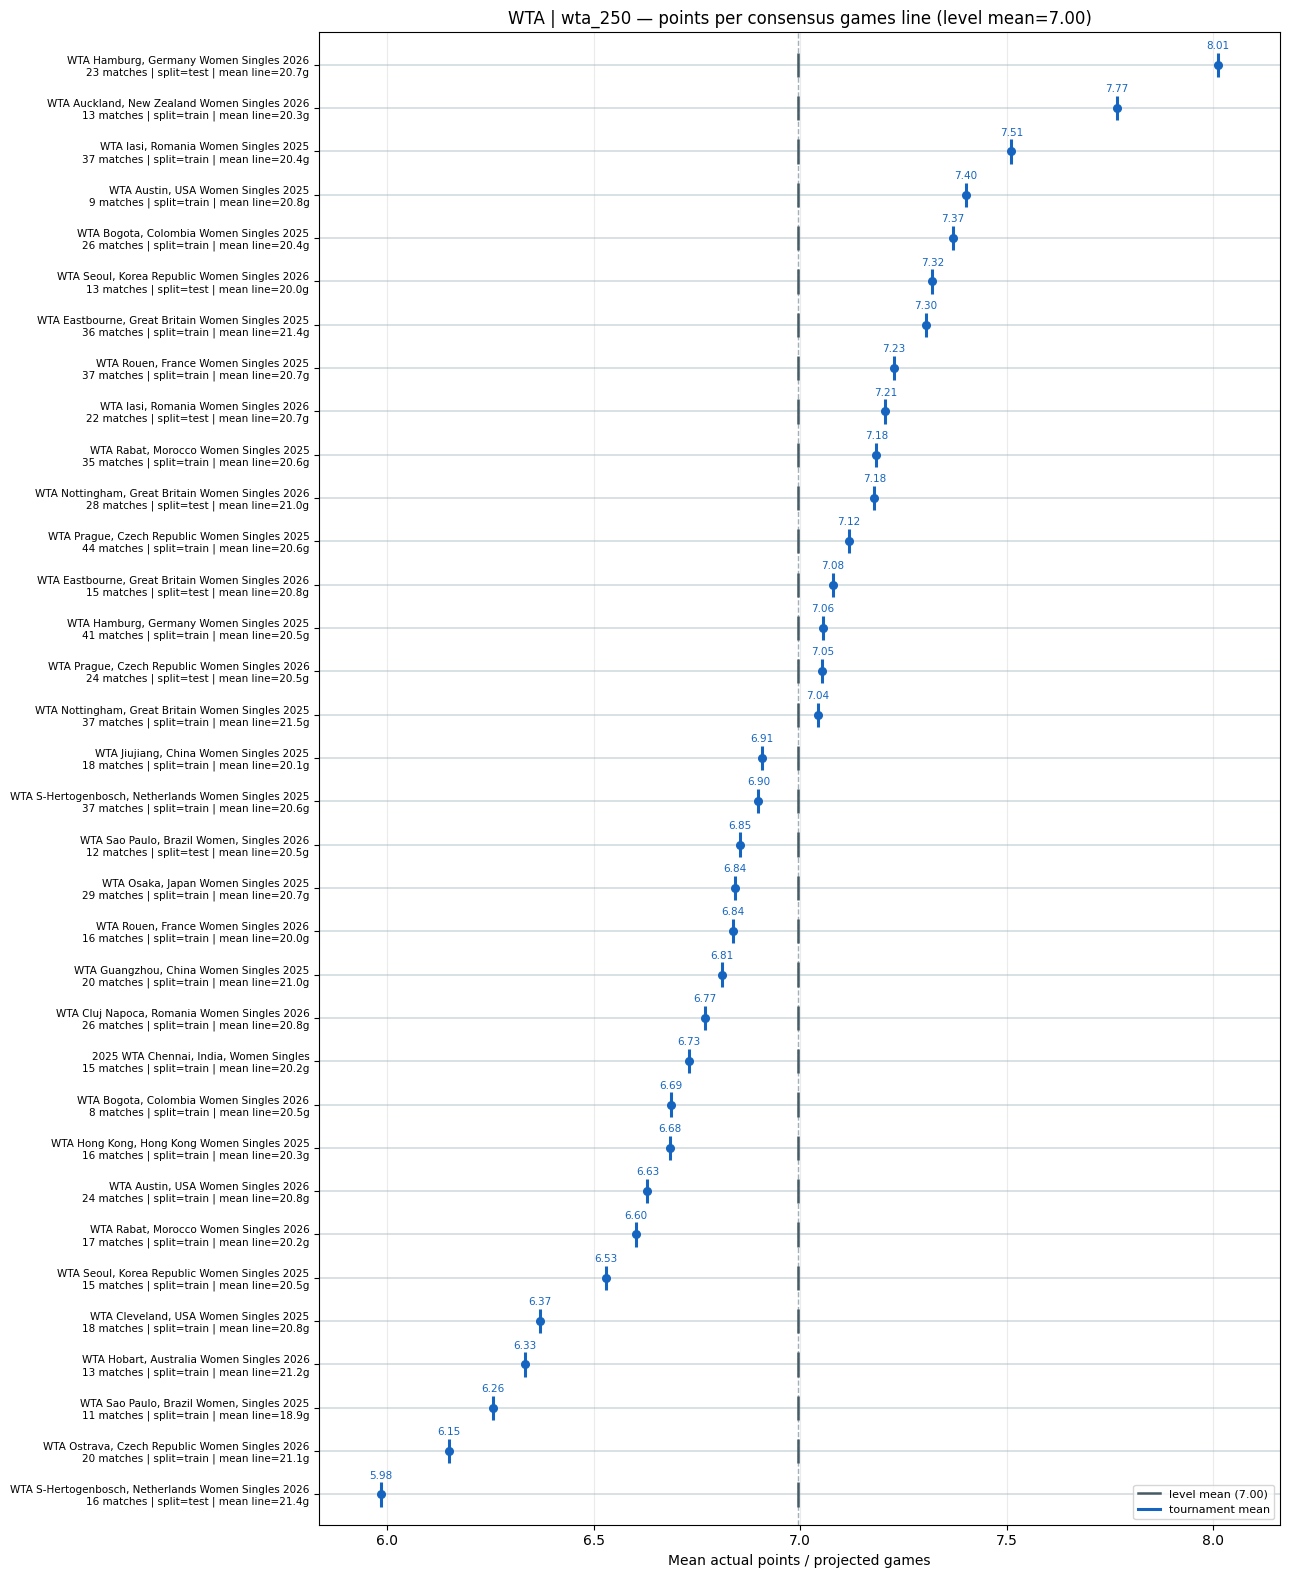

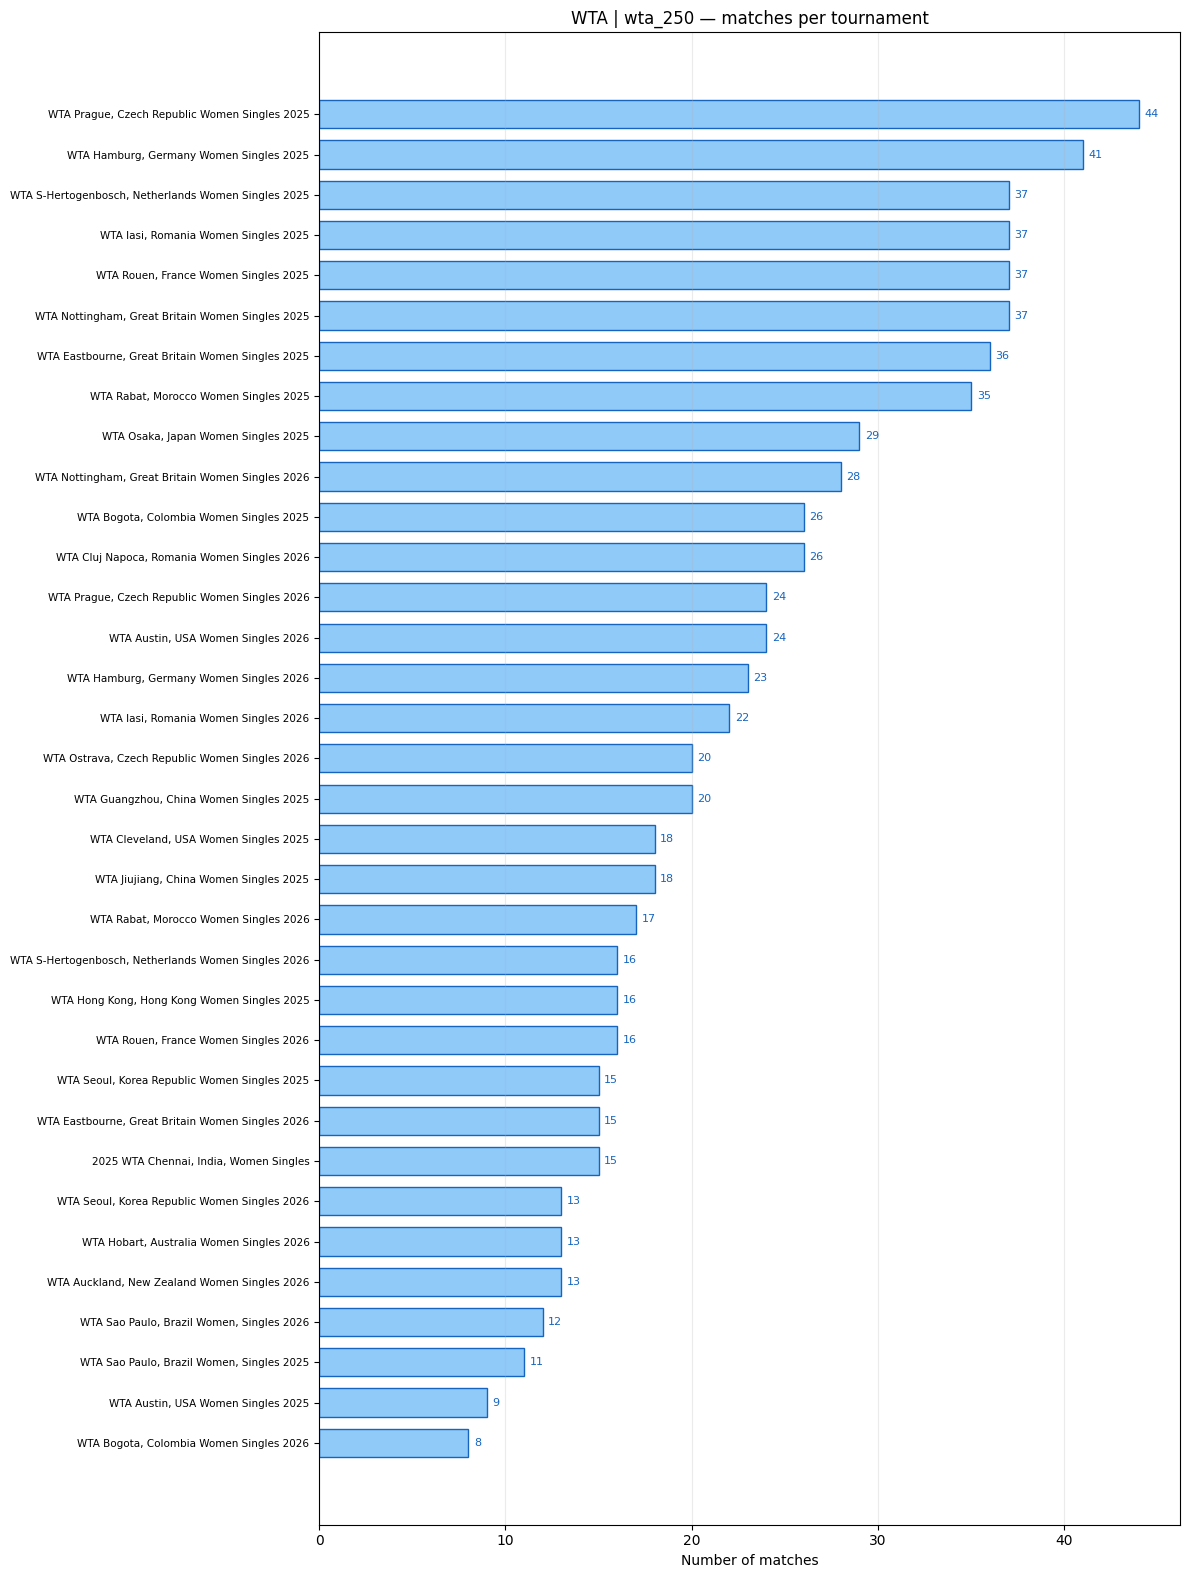

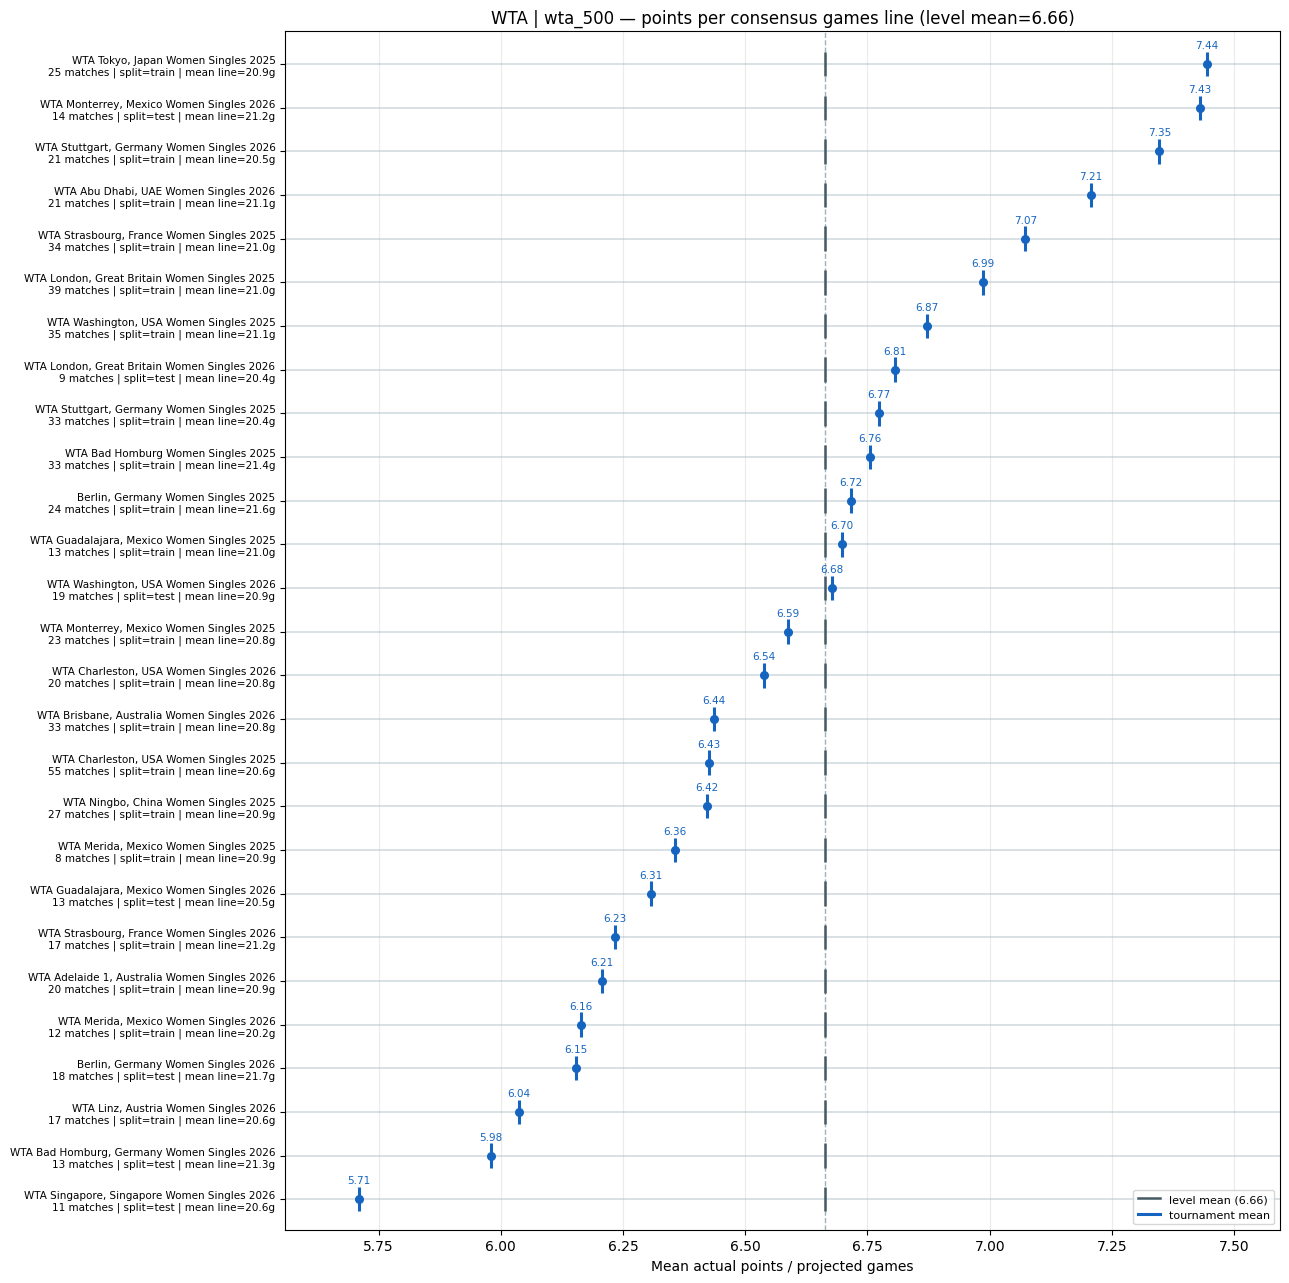

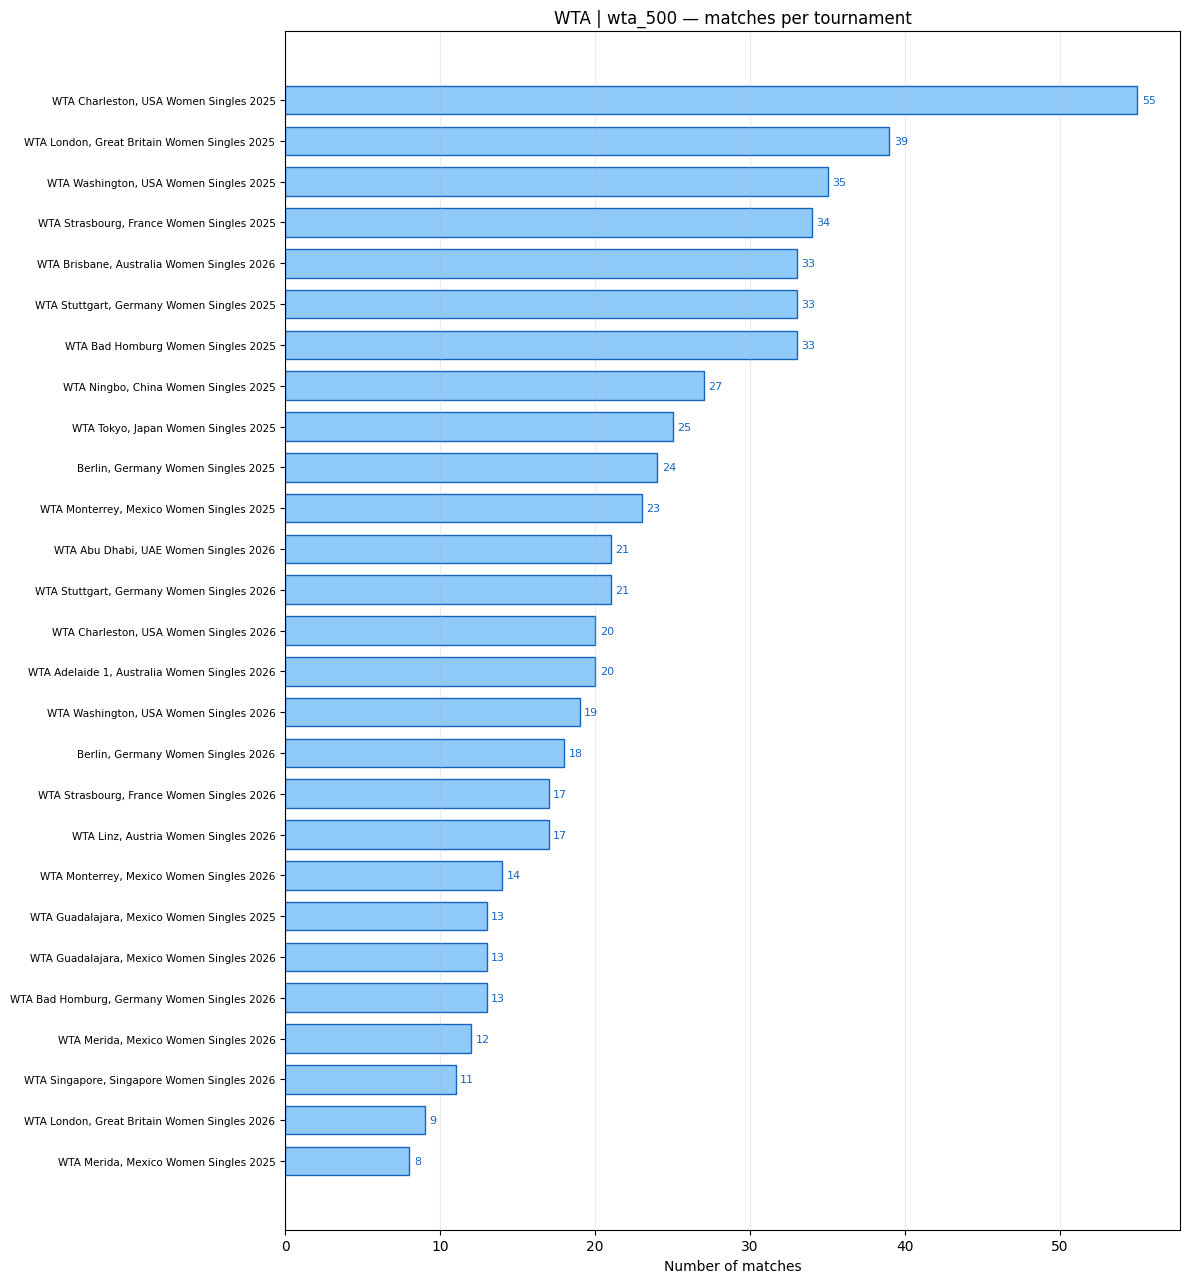

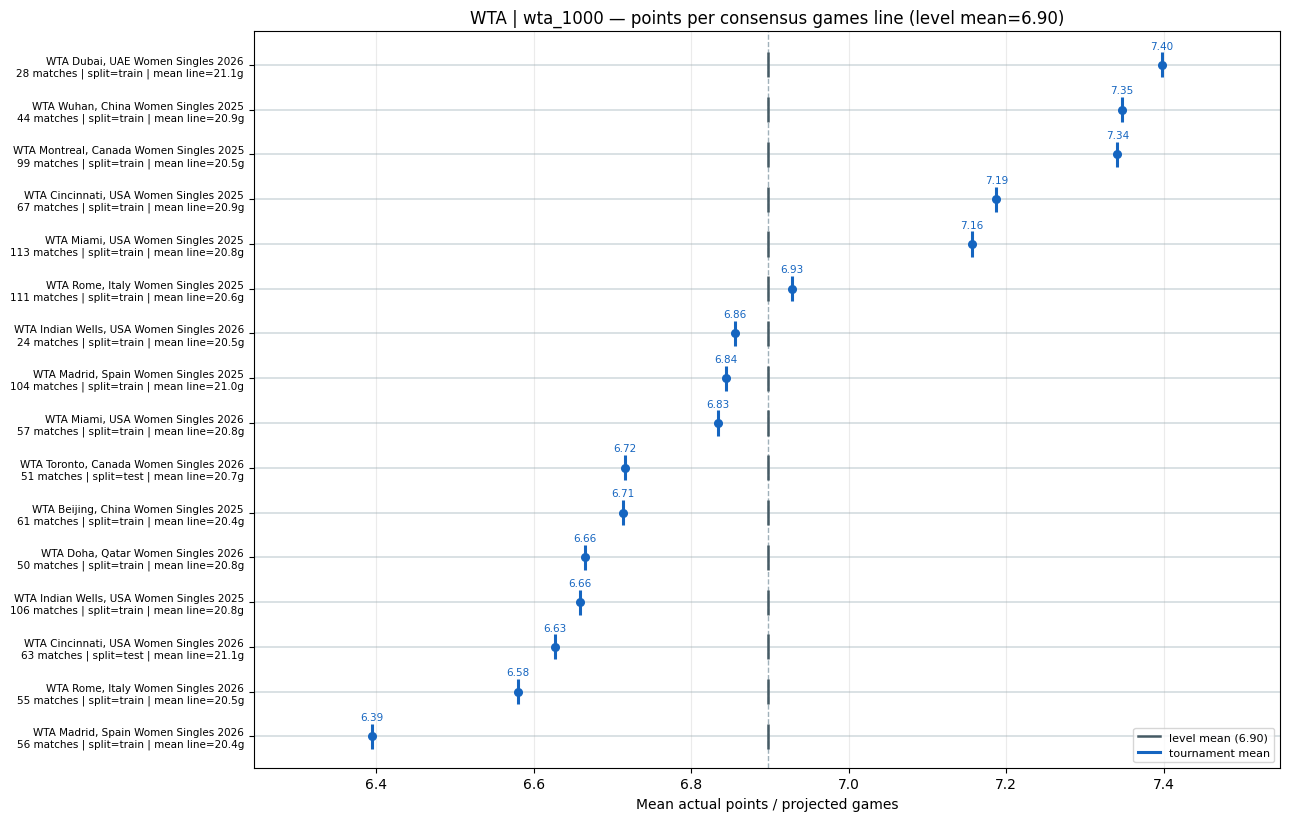

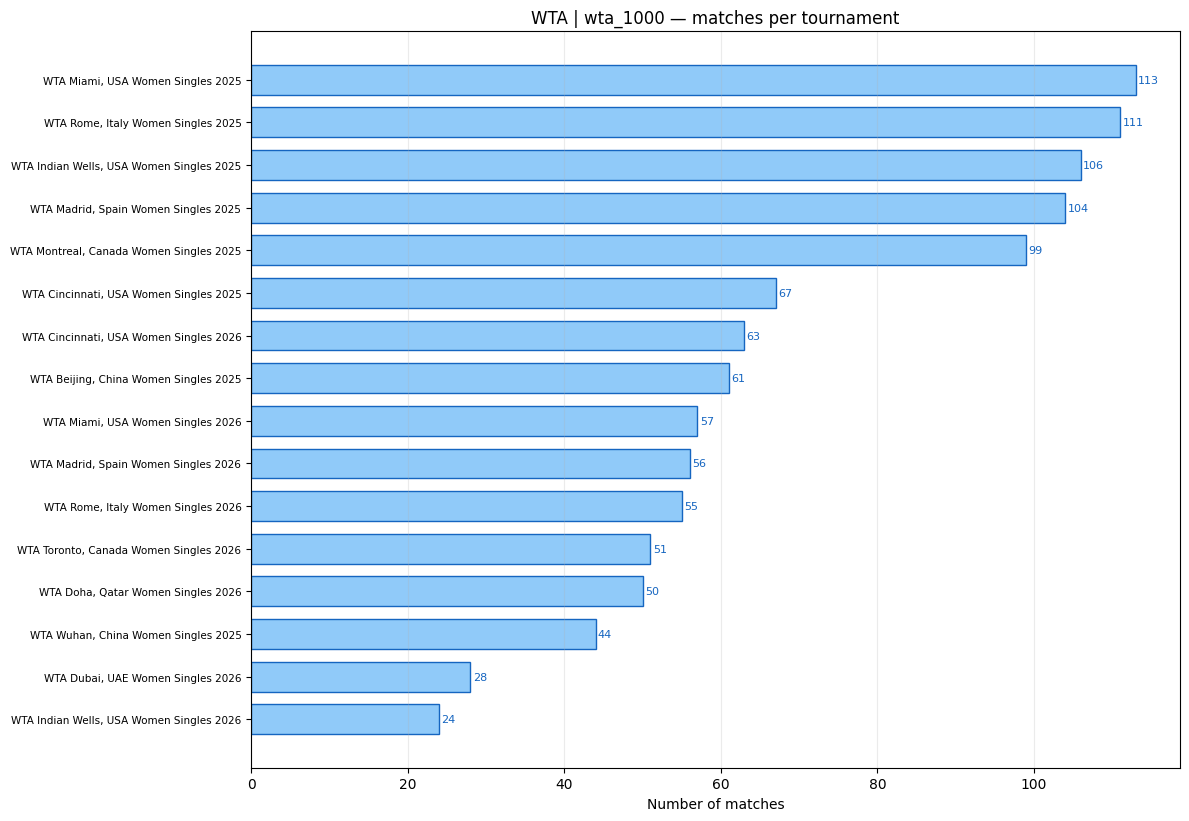

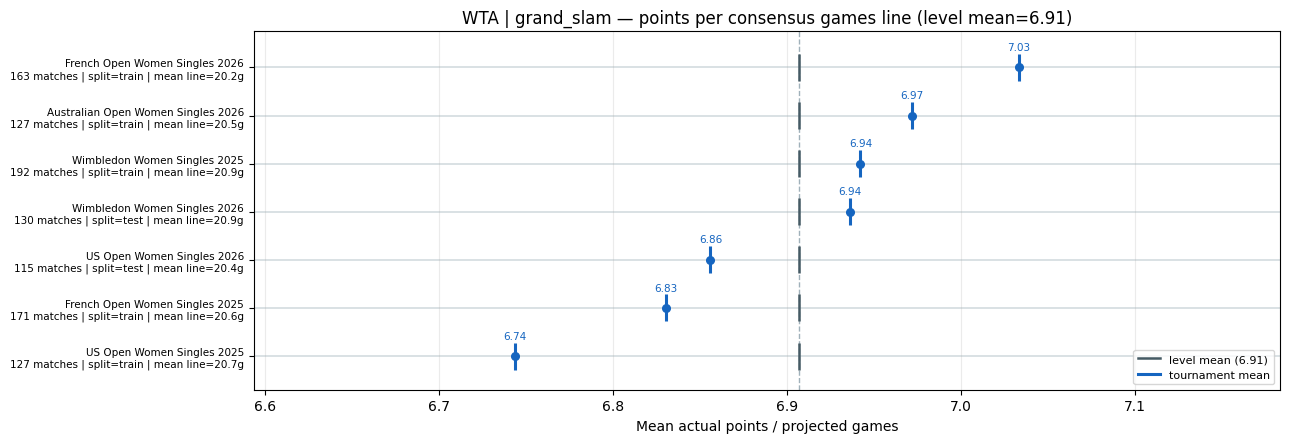

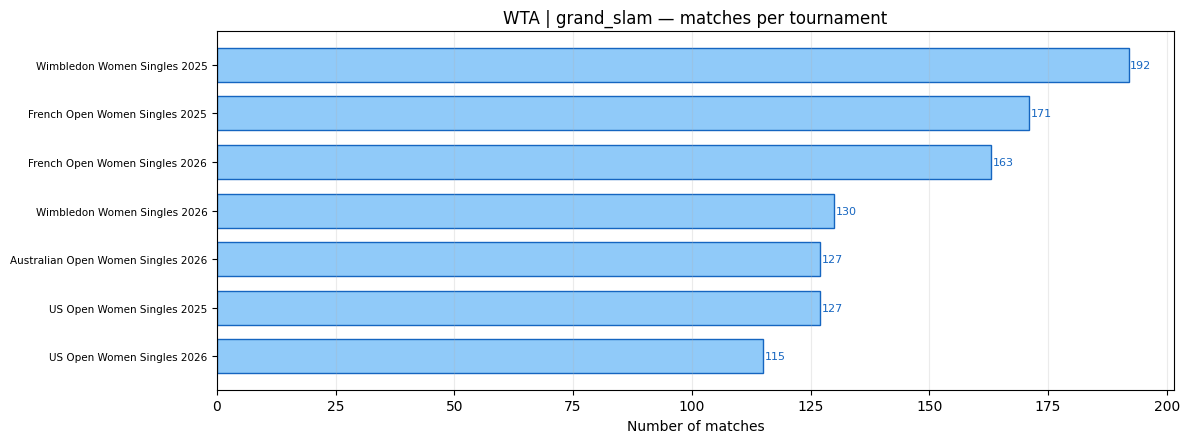

In [3]:
def tournament_summary(level_df: pd.DataFrame) -> pd.DataFrame:
    agg = {
        "season_name": ("season_name", "first"),
        "first_match_date": ("start_time", "min"),
        "n_matches": ("sport_event_id", "size"),
        "mean_points_per_proj_game": ("points_per_projected_game", "mean"),
        "mean_projected_games": ("projected_total_games", "mean"),
    }
    if "split" in level_df.columns:
        agg["split"] = ("split", "first")
    return (
        level_df.groupby("season_id", dropna=False)
        .agg(**agg)
        .reset_index()
        .sort_values("mean_points_per_proj_game", ascending=True)
        .reset_index(drop=True)
    )


def plot_points_per_proj_by_tournament(
    tourn_df: pd.DataFrame,
    *,
    level_label: str,
    overall_mean: float,
) -> None:
    plot_df = tourn_df.sort_values("mean_points_per_proj_game", ascending=True).reset_index(
        drop=True
    )
    if plot_df.empty:
        return

    y_pos = np.arange(len(plot_df))
    fig_h = max(4.0, 0.42 * len(plot_df) + 1.6)
    fig, ax = plt.subplots(figsize=(13, fig_h))

    x_min = float(min(plot_df["mean_points_per_proj_game"].min(), overall_mean) - 0.15)
    x_max = float(max(plot_df["mean_points_per_proj_game"].max(), overall_mean) + 0.15)

    for i, (_, row) in enumerate(plot_df.iterrows()):
        y = float(y_pos[i])
        x = float(row["mean_points_per_proj_game"])
        ax.hlines(y, x_min, x_max, color="#cfd8dc", linewidth=1.1, zorder=1)
        ax.vlines(overall_mean, y - 0.28, y + 0.28, color="#455a64", linewidth=1.8, zorder=3)
        ax.vlines(x, y - 0.28, y + 0.28, color="#1565c0", linewidth=2.2, zorder=4)
        ax.plot(x, y, "o", color="#1565c0", markersize=5.5, zorder=5)
        ax.text(
            x,
            y + 0.32,
            f"{x:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color="#1565c0",
        )

    ax.axvline(overall_mean, color="#90a4ae", linestyle="--", linewidth=1.0, alpha=0.85, zorder=0)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.7, len(plot_df) - 0.25)
    ax.set_yticks(y_pos)

    y_labels = []
    for _, row in plot_df.iterrows():
        name = str(row["season_name"]) if pd.notna(row["season_name"]) else str(row["season_id"])
        split = (
            str(row["split"])
            if ("split" in plot_df.columns and pd.notna(row["split"]))
            else "?"
        )
        y_labels.append(
            f"{name}\n"
            f"{int(row['n_matches'])} matches | split={split} | "
            f"mean line={row['mean_projected_games']:.1f}g"
        )
    ax.set_yticklabels(y_labels, fontsize=7.5)
    ax.set_xlabel("Mean actual points / projected games")
    ax.set_title(
        f"WTA | {level_label} — points per consensus games line "
        f"(level mean={overall_mean:.2f})"
    )
    ax.grid(axis="x", alpha=0.25)
    ax.plot([], [], color="#455a64", linewidth=1.8, label=f"level mean ({overall_mean:.2f})")
    ax.plot([], [], color="#1565c0", linewidth=2.2, label="tournament mean")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_matches_per_tournament(tourn_df: pd.DataFrame, *, level_label: str) -> None:
    count_df = tourn_df.sort_values("n_matches", ascending=True).reset_index(drop=True)
    if count_df.empty:
        return

    y_pos = np.arange(len(count_df))
    fig_h = max(4.0, 0.42 * len(count_df) + 1.6)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.barh(y_pos, count_df["n_matches"], color="#90caf9", edgecolor="#1565c0", height=0.7)
    for i, (_, row) in enumerate(count_df.iterrows()):
        ax.text(
            float(row["n_matches"]) + 0.3,
            float(y_pos[i]),
            f"{int(row['n_matches'])}",
            va="center",
            fontsize=8,
            color="#1565c0",
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [
            str(n) if pd.notna(n) else str(sid)
            for n, sid in zip(count_df["season_name"], count_df["season_id"], strict=True)
        ],
        fontsize=7.5,
    )
    ax.set_xlabel("Number of matches")
    ax.set_title(f"WTA | {level_label} — matches per tournament")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


for level in WOMEN_LEVELS:
    level_df = women.loc[women["competition_level"] == level].copy()
    if level_df.empty:
        continue
    tourn_df = tournament_summary(level_df)
    overall_mean = float(level_df["points_per_projected_game"].mean())
    plot_points_per_proj_by_tournament(
        tourn_df, level_label=level, overall_mean=overall_mean
    )
    plot_matches_per_tournament(tourn_df, level_label=level)